# 🔧 Notebook 02 — Feature Engineering & PICI Score
## ParkSense AI | Gridlock Round 2

**Input:** `data/processed/clean_violations.parquet` (from Notebook 01)  
**Output:** `data/processed/featured_violations.parquet` — enriched dataset with all ML-ready features

### What This Notebook Builds

| Feature Group | Features Created | Used By |
|---|---|---|
| **PICI Score** | violation severity, vehicle factor, junction mult, peak mult → `pici_score` | DBSCAN ranking, dashboard |
| **Vehicle enrichment** | `vehicle_category`, `vehicle_size_factor` | PICI, vehicle analysis chart |
| **Violation enrichment** | `severity_score`, `multi_vio_factor`, `has_double_parking`, etc. | PICI, violation breakdown |
| **Geospatial grid** | `lat_grid`, `lng_grid`, `grid_cell` | Hotspot aggregation, clustering |
| **Temporal enrichment** | `time_of_day`, `is_business_hours`, `season` | Temporal patterns, XGBoost |
| **Enforcement gaps** | `validation_lag_hours`, `enforcement_gap_flag` | Station dashboard |
| **Repeat offender** | `vehicle_prior_violations`, `is_repeat_offender` | Repeat offenders panel |
| **Area context** | `road_type_hint`, `area_name` (from location string) | Map tooltips |

---
> **⚠️ Rule:** All features derived ONLY from the provided CSV. No external data used.

## 0. Setup & Load Clean Data

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import re
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 11

print('✅ Imports done.')

✅ Imports done.


In [20]:
import json
CLEAN_PATH = '../data/processed/clean_violations.parquet'
df = pd.read_parquet(CLEAN_PATH)

def safe_load(x):
    if isinstance(x, list): return x
    try:
        return json.loads(x)
    except:
        import ast
        try: return ast.literal_eval(x)
        except: return []

df['violation_list'] = df['violation_list'].apply(safe_load)
if 'offence_code_list' in df.columns:
    df['offence_code_list'] = df['offence_code_list'].apply(safe_load)

print(f'Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'Columns: {list(df.columns)}')


Loaded: 115,353 rows × 46 columns
Columns: ['id', 'latitude', 'longitude', 'location', 'vehicle_number', 'vehicle_type', 'violation_type', 'offence_code', 'created_datetime', 'closed_datetime', 'modified_datetime', 'device_id', 'created_by_id', 'center_code', 'police_station', 'data_sent_to_scita', 'junction_name', 'action_taken_timestamp', 'data_sent_to_scita_timestamp', 'updated_vehicle_number', 'updated_vehicle_type', 'validation_status', 'validation_timestamp', 'violation_list', 'offence_code_list', 'violation_count', 'has_wrong_parking', 'has_no_parking', 'has_parking_in_a_main_road', 'has_double_parking', 'has_parking_opposite_to_another_parked_vehicle', 'has_parking_near_bustop_school_hospital_etc', 'has_parking_near_road_crossing', 'has_defective_number_plate', 'hour', 'day_of_week', 'day_name', 'month', 'month_name', 'week_of_year', 'date', 'is_peak_hour', 'is_weekend', 'final_vehicle_type', 'has_junction', 'final_vehicle_number']


In [21]:
# Quick sanity check — all should be approved with valid GPS
print('validation_status distribution:')
print(df['validation_status'].value_counts(dropna=False))
print(f'\nLatitude nulls  : {df["latitude"].isna().sum()}')
print(f'Longitude nulls : {df["longitude"].isna().sum()}')
print(f'Date range      : {df["created_datetime"].min()} → {df["created_datetime"].max()}')

validation_status distribution:
validation_status
approved    115353
Name: count, dtype: int64

Latitude nulls  : 0
Longitude nulls : 0
Date range      : 2023-11-10 00:41:46+05:30 → 2024-03-29 08:38:46+05:30


## 1. Vehicle Feature Engineering

### 1A. Understanding Vehicle Types From EDA
From Notebook 01 we saw the following `final_vehicle_type` values:  
`CAR, SCOOTER, MOTOR CYCLE, MAXI-CAB, TANKER, PASSENGER AUTO, VAN, LGV, MOPED, GOODS AUTO, BUS, OTHERS`

### 1B. Vehicle Categories (for PICI)
Per approach strategy:
- **HEAVY** (2.0): TANKER, BUS, TRUCK, LGV (Large Goods Vehicle)
- **MEDIUM** (1.5): CAR, MAXI-CAB, VAN  
- **LIGHT** (1.2): PASSENGER AUTO, GOODS AUTO
- **TWO_WHEELER** (1.0): SCOOTER, MOTOR CYCLE, MOPED
- **UNKNOWN** (1.0): OTHERS — give minimum multiplier

In [22]:
# Vehicle size factor mapping — based on road blockage footprint
# Source: Approach Strategy, Section 9
VEHICLE_SIZE_FACTOR = {
    # HEAVY — largest footprint, maximum blockage
    'TANKER'      : 2.0,
    'BUS'         : 2.0,
    'TRUCK'       : 2.0,
    'LGV'         : 2.0,   # Large Goods Vehicle
    # MEDIUM
    'CAR'         : 1.5,
    'MAXI-CAB'    : 1.5,
    'VAN'         : 1.5,
    # LIGHT
    'PASSENGER AUTO': 1.2,
    'GOODS AUTO'  : 1.2,
    # TWO-WHEELER — smallest footprint
    'SCOOTER'     : 1.0,
    'MOTOR CYCLE' : 1.0,
    'MOPED'       : 1.0,
    # UNKNOWN — conservative minimum
    'OTHERS'      : 1.0,
}

VEHICLE_CATEGORY = {
    'TANKER'        : 'HEAVY',
    'BUS'           : 'HEAVY',
    'TRUCK'         : 'HEAVY',
    'LGV'           : 'HEAVY',
    'CAR'           : 'MEDIUM',
    'MAXI-CAB'      : 'MEDIUM',
    'VAN'           : 'MEDIUM',
    'PASSENGER AUTO': 'LIGHT',
    'GOODS AUTO'    : 'LIGHT',
    'SCOOTER'       : 'TWO_WHEELER',
    'MOTOR CYCLE'   : 'TWO_WHEELER',
    'MOPED'         : 'TWO_WHEELER',
    'OTHERS'        : 'UNKNOWN',
}

# Apply — if a new vehicle type appears in uploaded data, default to 1.0
df['vehicle_size_factor'] = df['final_vehicle_type'].map(VEHICLE_SIZE_FACTOR).fillna(1.0)
df['vehicle_category']    = df['final_vehicle_type'].map(VEHICLE_CATEGORY).fillna('UNKNOWN')

print('Vehicle category distribution:')
print(df['vehicle_category'].value_counts())
print()
print('Vehicle size factor distribution:')
print(df['vehicle_size_factor'].value_counts().sort_index(ascending=False))

Vehicle category distribution:
vehicle_category
TWO_WHEELER    52505
MEDIUM         41540
LIGHT          14802
HEAVY           3288
UNKNOWN         3218
Name: count, dtype: int64

Vehicle size factor distribution:
vehicle_size_factor
2.0     3288
1.5    41540
1.2    14802
1.0    55723
Name: count, dtype: int64


In [23]:
# Check: are there any vehicle types in the data NOT in our mapping?
unmapped = df[df['vehicle_size_factor'] == 1.0]['final_vehicle_type'].unique()
print('Vehicle types mapped to default factor 1.0 (check these):')
for v in unmapped:
    if v not in VEHICLE_SIZE_FACTOR:
        print(f'  ⚠️  UNMAPPED: {v}')
    else:
        print(f'  ✅  Correctly mapped: {v}')

Vehicle types mapped to default factor 1.0 (check these):
  ✅  Correctly mapped: MOTOR CYCLE
  ✅  Correctly mapped: SCOOTER
  ✅  Correctly mapped: OTHERS
  ⚠️  UNMAPPED: JEEP
  ✅  Correctly mapped: MOPED
  ⚠️  UNMAPPED: PRIVATE BUS
  ⚠️  UNMAPPED: MINI LORRY
  ⚠️  UNMAPPED: HGV
  ⚠️  UNMAPPED: TEMPO
  ⚠️  UNMAPPED: SCHOOL VEHICLE
  ⚠️  UNMAPPED: TOURIST BUS
  ⚠️  UNMAPPED: LORRY/GOODS VEHICLE
  ⚠️  UNMAPPED: TRACTOR
  ⚠️  UNMAPPED: BUS (BMTC/KSRTC)
  ⚠️  UNMAPPED: FACTORY BUS


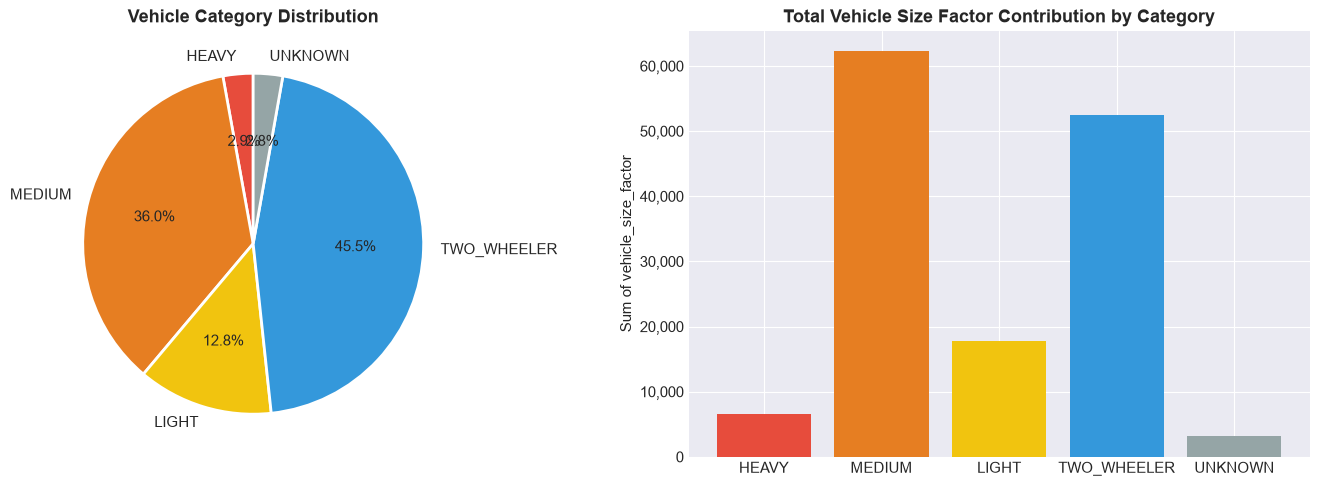

In [24]:
# Visualise vehicle category proportions
cat_order = ['HEAVY', 'MEDIUM', 'LIGHT', 'TWO_WHEELER', 'UNKNOWN']
cat_colors = ['#e74c3c', '#e67e22', '#f1c40f', '#3498db', '#95a5a6']
cat_counts = df['vehicle_category'].value_counts().reindex(cat_order, fill_value=0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Pie
ax1.pie(cat_counts.values, labels=cat_counts.index, colors=cat_colors,
        autopct='%1.1f%%', startangle=90, wedgeprops=dict(edgecolor='white', linewidth=2))
ax1.set_title('Vehicle Category Distribution', fontweight='bold')

# Bar by category showing % of total PICI weight contribution
cat_weight_sum = df.groupby('vehicle_category')['vehicle_size_factor'].sum().reindex(cat_order, fill_value=0)
ax2.bar(cat_weight_sum.index, cat_weight_sum.values, color=cat_colors)
ax2.set_title('Total Vehicle Size Factor Contribution by Category', fontweight='bold')
ax2.set_ylabel('Sum of vehicle_size_factor')
ax2.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.show()

## 2. Violation Severity Score

### The Formula Per Record:
```
severity_score = Σ SEVERITY_WEIGHT[v] for v in violation_list
                 (excluding DEFECTIVE NUMBER PLATE — non-parking offence)
```

### Why These Weights (from Approach Strategy Section 9):
- **DOUBLE PARKING = 10**: Physically blocks a lane — hardest congestion impact
- **PARKING OPPOSITE TO ANOTHER = 9**: Creates a pinch point, narrows road to one lane
- **PARKING IN A MAIN ROAD = 8**: Main roads carry high traffic — impact multiplies
- **PARKING NEAR ROAD CROSSING = 7**: Blocks intersection sightlines — safety + flow
- **PARKING NEAR BUSTOP/SCHOOL/HOSPITAL = 6**: High pedestrian+vehicle conflict zone
- **WRONG PARKING = 4**: General misplacement, varies in impact
- **NO PARKING = 3**: Designated zone violation — may not always block traffic

In [25]:
# Violation severity weights — from Approach Strategy
SEVERITY_WEIGHTS = {
    'DOUBLE PARKING'                                : 10,
    'PARKING OPPOSITE TO ANOTHER PARKED VEHICLE'    :  9,
    'PARKING IN A MAIN ROAD'                        :  8,
    'PARKING NEAR ROAD CROSSING'                    :  7,
    'PARKING NEAR BUSTOP/SCHOOL/HOSPITAL ETC'       :  6,
    'WRONG PARKING'                                 :  4,
    'NO PARKING'                                    :  3,
    # DEFECTIVE NUMBER PLATE is intentionally excluded (non-parking offence)
    'DEFECTIVE NUMBER PLATE'                        :  0,
}

def compute_severity_score(violation_list):
    """
    Sum severity weights for all parking violations in a record.
    DEFECTIVE NUMBER PLATE contributes 0 (excluded from PICI).
    Unknown violation types get weight 2 (conservative default).
    """
    if not violation_list:
        return 0
    total = 0
    for v in violation_list:
        total += SEVERITY_WEIGHTS.get(v, 2)  # default 2 for any future unknown type
    return total

# Handle case where violation_list column might be stored as string in parquet
# (parquet preserves Python lists if saved from pandas with list dtype)
if df['violation_list'].dtype == object:
    # If stored as string representations, re-evaluate them
    import ast
    df['violation_list'] = df['violation_list'].apply(
        lambda x: ast.literal_eval(x) if isinstance(x, str) else (x if isinstance(x, list) else [])
    )

df['severity_score'] = df['violation_list'].apply(compute_severity_score)

print('Severity score distribution:')
print(df['severity_score'].describe().round(2))
print()
print('Severity score value counts (top 15):')
print(df['severity_score'].value_counts().sort_index(ascending=False).head(15))

Severity score distribution:
count    115353.00
mean          4.35
std           2.89
min           3.00
25%           3.00
50%           4.00
75%           4.00
max          51.00
Name: severity_score, dtype: float64

Severity score value counts (top 15):
severity_score
51     1
49     5
47     1
45     1
44     1
43     6
42     3
41     4
40    30
39     2
38     2
37     6
36     3
34     9
33     4
Name: count, dtype: int64


In [26]:
# Validate: show examples of high and low severity records
print('=== HIGH SEVERITY records (top 5) ===')
high_sev = df.nlargest(5, 'severity_score')[['id','severity_score','violation_list','final_vehicle_type','junction_name']]
for _, row in high_sev.iterrows():
    print(f"  ID: {row['id']} | Score: {row['severity_score']} | Violations: {row['violation_list']}")

print()
print('=== LOW SEVERITY records (bottom 5, score=3 NO PARKING) ===')
low_sev = df[df['severity_score'] == 3].head(5)[['id','severity_score','violation_list','final_vehicle_type','junction_name']]
for _, row in low_sev.iterrows():
    print(f"  ID: {row['id']} | Score: {row['severity_score']} | Violations: {row['violation_list']}")

=== HIGH SEVERITY records (top 5) ===
  ID: FKID001115 | Score: 51 | Violations: ['NO PARKING', 'WRONG PARKING', 'PARKING NEAR BUSTOP/SCHOOL/HOSPITAL ETC', 'DOUBLE PARKING', 'PARKING OPPOSITE TO ANOTHER PARKED VEHICLE', 'PARKING NEAR TRAFFIC LIGHT OR ZEBRA CROSS', 'PARKING NEAR ROAD CROSSING', 'PARKING OTHER THAN BUS STOP', 'PARKING IN A MAIN ROAD']
  ID: FKID001095 | Score: 49 | Violations: ['NO PARKING', 'WRONG PARKING', 'PARKING NEAR BUSTOP/SCHOOL/HOSPITAL ETC', 'DOUBLE PARKING', 'PARKING OPPOSITE TO ANOTHER PARKED VEHICLE', 'PARKING IN A MAIN ROAD', 'PARKING NEAR ROAD CROSSING', 'USING BLACK FILM/OTHER MATERIALS']
  ID: FKID001074 | Score: 49 | Violations: ['NO PARKING', 'WRONG PARKING', 'PARKING NEAR BUSTOP/SCHOOL/HOSPITAL ETC', 'DOUBLE PARKING', 'PARKING OPPOSITE TO ANOTHER PARKED VEHICLE', 'PARKING IN A MAIN ROAD', 'PARKING NEAR ROAD CROSSING', 'USING BLACK FILM/OTHER MATERIALS']
  ID: FKID001117 | Score: 49 | Violations: ['NO PARKING', 'WRONG PARKING', 'PARKING NEAR BUSTOP/SCHO

In [27]:
# Multi-violation factor: records with more simultaneous violations are worse
# Formula: base 1.0 + 0.1 bonus per additional violation beyond the first
# So: 1 violation → 1.0 | 2 violations → 1.1 | 6 violations → 1.5
# Cap at 1.5 to avoid over-penalizing edge cases with many small violations

# Re-count parking violations only (exclude DEFECTIVE NUMBER PLATE)
df['parking_violation_count'] = df['violation_list'].apply(
    lambda lst: sum(1 for v in lst if v != 'DEFECTIVE NUMBER PLATE')
)

df['multi_vio_factor'] = df['parking_violation_count'].apply(
    lambda n: min(1.0 + 0.1 * max(0, n - 1), 1.5)
)

print('Multi-violation factor distribution:')
print(df['multi_vio_factor'].value_counts().sort_index(ascending=False))
print()
print('Parking violation count distribution:')
print(df['parking_violation_count'].value_counts().sort_index())

Multi-violation factor distribution:
multi_vio_factor
1.5        85
1.4        71
1.3       328
1.2      1651
1.1      9867
1.0    103351
Name: count, dtype: int64

Parking violation count distribution:
parking_violation_count
1    103351
2      9867
3      1651
4       328
5        71
6        61
7        15
8         8
9         1
Name: count, dtype: int64


## 3. Junction & Temporal Multipliers

In [28]:
# Junction multiplier — already have has_junction from EDA
# If not present (e.g., loaded from parquet without it), recompute
if 'has_junction' not in df.columns:
    df['has_junction'] = df['junction_name'].apply(
        lambda x: 0 if (pd.isna(x) or str(x).strip() == 'No Junction') else 1
    )

# Per approach strategy: junction × 2.0, no junction × 1.0
df['junction_multiplier'] = df['has_junction'].map({1: 2.0, 0: 1.0})

print('Junction multiplier distribution:')
print(df['junction_multiplier'].value_counts())
print(f'\nViolations at named junctions: {df["has_junction"].mean()*100:.1f}%')

Junction multiplier distribution:
junction_multiplier
2.0    60893
1.0    54460
Name: count, dtype: int64

Violations at named junctions: 52.8%


In [29]:
# Peak hour multiplier — already have is_peak_hour from EDA
# If not present, recompute
if 'is_peak_hour' not in df.columns:
    if 'hour' not in df.columns:
        df['hour'] = df['created_datetime'].dt.hour.fillna(-1).astype('int64')
    df['is_peak_hour'] = df['hour'].apply(
        lambda h: 1 if (8 <= h <= 11) or (17 <= h <= 21) else 0
    )

# Per approach strategy: peak × 1.5, off-peak × 1.0
df['peak_hour_multiplier'] = df['is_peak_hour'].map({1: 1.5, 0: 1.0})

print('Peak hour multiplier distribution:')
print(df['peak_hour_multiplier'].value_counts())
print(f'\nPeak hour violations: {df["is_peak_hour"].mean()*100:.1f}%')

Peak hour multiplier distribution:
peak_hour_multiplier
1.0    70347
1.5    45006
Name: count, dtype: int64

Peak hour violations: 39.0%


## 4. PICI Score Computation

### The Full Formula (Per-Record Level):

$$\text{PICI}_{raw} = \text{severity\_score} \times \text{vehicle\_size\_factor} \times \text{junction\_multiplier} \times \text{peak\_hour\_multiplier} \times \text{multi\_vio\_factor}$$

Then **normalize to 0–10 scale** using min-max normalization so the score is human-readable.

### Theoretical Range:
- **Min possible:** `3 × 1.0 × 1.0 × 1.0 × 1.0 = 3.0` (NO PARKING, scooter, mid-block, off-peak, single violation)
- **Max possible:** `(10+9+8+7+6+4+3) × 2.0 × 2.0 × 1.5 × 1.5 = 47 × 2.0 × 2.0 × 1.5 × 1.5 = 423.0` (all violations, tanker, junction, peak, 7 violations)

In practice, most records will be in a much smaller range.

In [30]:
# Compute raw PICI score per record
df['pici_raw'] = (
    df['severity_score']
    * df['vehicle_size_factor']
    * df['junction_multiplier']
    * df['peak_hour_multiplier']
    * df['multi_vio_factor']
)

print('Raw PICI score statistics:')
print(df['pici_raw'].describe().round(2))
print(f'\nMin raw PICI: {df["pici_raw"].min()}')
print(f'Max raw PICI: {df["pici_raw"].max()}')

Raw PICI score statistics:
count    115353.00
mean          9.81
std           8.22
min           3.00
25%           6.00
50%           8.00
75%          12.00
max         405.00
Name: pici_raw, dtype: float64

Min raw PICI: 3.0
Max raw PICI: 405.0


In [31]:
# Normalize raw PICI to 0–10 scale using min-max normalization
pici_min = df['pici_raw'].min()
pici_max = df['pici_raw'].max()

df['pici_score'] = ((df['pici_raw'] - pici_min) / (pici_max - pici_min) * 10).round(3)

# Store normalization params — needed by backend to normalize new data the SAME way
PICI_NORM_PARAMS = {
    'pici_min': float(pici_min),
    'pici_max': float(pici_max)
}

print('Normalized PICI score (0–10) statistics:')
print(df['pici_score'].describe().round(3))

Normalized PICI score (0–10) statistics:
count    115353.000
mean          0.169
std           0.205
min           0.000
25%           0.075
50%           0.124
75%           0.224
max          10.000
Name: pici_score, dtype: float64


In [32]:
# ============================================================
# VALIDATION — The PICI Score Must Make Intuitive Sense
# ============================================================

print('=== PICI SCORE VALIDATION ===')
print()

# Expected HIGH: DOUBLE PARKING + TANKER + named junction + peak hour
high_case = df[
    (df['vehicle_category'] == 'HEAVY') &
    (df['has_junction'] == 1) &
    (df['is_peak_hour'] == 1) &
    (df['violation_list'].apply(lambda x: 'DOUBLE PARKING' in x))
].head(3)
print('EXPECTED HIGH PICI: Heavy vehicle + junction + peak hour + double parking')
if len(high_case) > 0:
    for _, r in high_case.iterrows():
        print(f"  pici={r['pici_score']:.2f} | {r['final_vehicle_type']} | {str(r['junction_name'])[:40]} | {r['violation_list']}")
else:
    print('  No matching records found (combination may be rare)')

print()
# Expected LOW: NO PARKING + scooter + no junction + off-peak
low_case = df[
    (df['vehicle_category'] == 'TWO_WHEELER') &
    (df['has_junction'] == 0) &
    (df['is_peak_hour'] == 0) &
    (df['parking_violation_count'] == 1) &
    (df['violation_list'].apply(lambda x: x == ['NO PARKING']))
].head(3)
print('EXPECTED LOW PICI: Two-wheeler + no junction + off-peak + only NO PARKING')
if len(low_case) > 0:
    for _, r in low_case.iterrows():
        print(f"  pici={r['pici_score']:.2f} | {r['final_vehicle_type']} | junction={r['has_junction']} | peak={r['is_peak_hour']}")

print()
print('Overall PICI score percentiles:')
for p in [10, 25, 50, 75, 90, 95, 99]:
    print(f'  P{p:02d}: {np.percentile(df["pici_score"], p):.3f}')

=== PICI SCORE VALIDATION ===

EXPECTED HIGH PICI: Heavy vehicle + junction + peak hour + double parking
  pici=2.06 | LGV | BTP075 - Police Corner | ['NO PARKING', 'DOUBLE PARKING']
  pici=2.06 | LGV | BTP080 - NR Road, SP Road Junction | ['NO PARKING', 'DOUBLE PARKING']
  pici=2.06 | LGV | BTP080 - NR Road, SP Road Junction | ['NO PARKING', 'DOUBLE PARKING']

EXPECTED LOW PICI: Two-wheeler + no junction + off-peak + only NO PARKING
  pici=0.00 | SCOOTER | junction=0 | peak=0
  pici=0.00 | SCOOTER | junction=0 | peak=0
  pici=0.00 | SCOOTER | junction=0 | peak=0

Overall PICI score percentiles:
  P10: 0.025
  P25: 0.075
  P50: 0.124
  P75: 0.224
  P90: 0.373
  P95: 0.463
  P99: 1.009


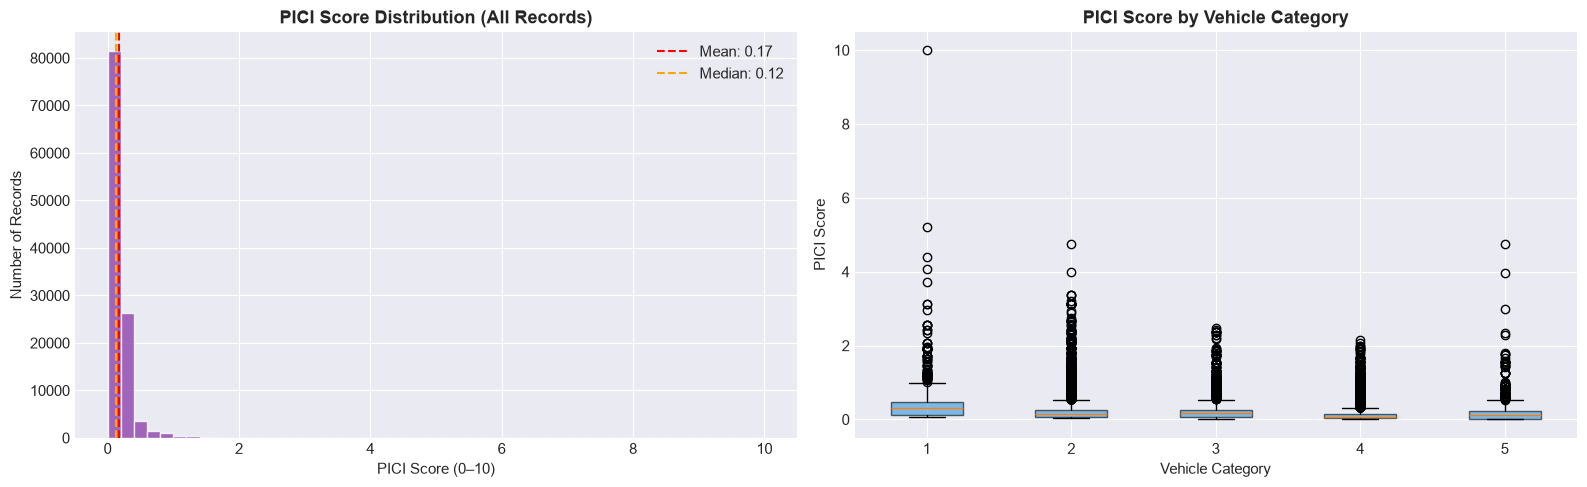

In [33]:
# PICI Score distribution visualisation
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Histogram
ax1.hist(df['pici_score'], bins=50, color='#8e44ad', alpha=0.8, edgecolor='white')
ax1.set_xlabel('PICI Score (0–10)')
ax1.set_ylabel('Number of Records')
ax1.set_title('PICI Score Distribution (All Records)', fontweight='bold')
ax1.axvline(df['pici_score'].mean(), color='red', linestyle='--', label=f'Mean: {df["pici_score"].mean():.2f}')
ax1.axvline(df['pici_score'].median(), color='orange', linestyle='--', label=f'Median: {df["pici_score"].median():.2f}')
ax1.legend()

# PICI by vehicle category (box plot)
cat_order = ['HEAVY', 'MEDIUM', 'LIGHT', 'TWO_WHEELER', 'UNKNOWN']
data_by_cat = [df[df['vehicle_category'] == c]['pici_score'].values for c in cat_order if c in df['vehicle_category'].values]
cat_labels = [c for c in cat_order if c in df['vehicle_category'].values]
ax2.boxplot(data_by_cat, label=cat_labels, patch_artist=True,
            boxprops=dict(facecolor='#3498db', alpha=0.6))
ax2.set_xlabel('Vehicle Category')
ax2.set_ylabel('PICI Score')
ax2.set_title('PICI Score by Vehicle Category', fontweight='bold')

plt.tight_layout()
plt.show()

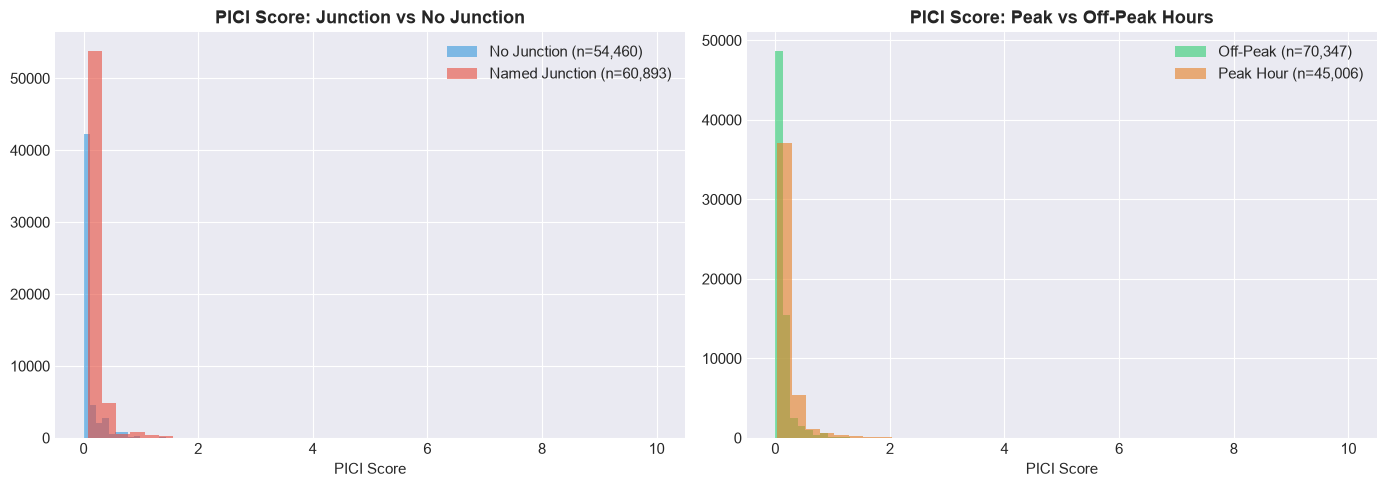

Mean PICI at junction    : 0.219
Mean PICI no junction    : 0.114
Mean PICI at peak hour   : 0.229
Mean PICI off-peak       : 0.131


In [34]:
# PICI score comparison: Junction vs No Junction AND Peak vs Off-Peak
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Junction impact
pici_junction = df[df['has_junction'] == 1]['pici_score']
pici_no_junc  = df[df['has_junction'] == 0]['pici_score']
ax1.hist(pici_no_junc,  bins=40, alpha=0.6, color='#3498db', label=f'No Junction (n={len(pici_no_junc):,})')
ax1.hist(pici_junction, bins=40, alpha=0.6, color='#e74c3c', label=f'Named Junction (n={len(pici_junction):,})')
ax1.set_xlabel('PICI Score')
ax1.set_title('PICI Score: Junction vs No Junction', fontweight='bold')
ax1.legend()

# Peak hour impact
pici_peak    = df[df['is_peak_hour'] == 1]['pici_score']
pici_offpeak = df[df['is_peak_hour'] == 0]['pici_score']
ax2.hist(pici_offpeak, bins=40, alpha=0.6, color='#2ecc71', label=f'Off-Peak (n={len(pici_offpeak):,})')
ax2.hist(pici_peak,    bins=40, alpha=0.6, color='#e67e22', label=f'Peak Hour (n={len(pici_peak):,})')
ax2.set_xlabel('PICI Score')
ax2.set_title('PICI Score: Peak vs Off-Peak Hours', fontweight='bold')
ax2.legend()

plt.tight_layout()
plt.show()

print(f'Mean PICI at junction    : {pici_junction.mean():.3f}')
print(f'Mean PICI no junction    : {pici_no_junc.mean():.3f}')
print(f'Mean PICI at peak hour   : {pici_peak.mean():.3f}')
print(f'Mean PICI off-peak       : {pici_offpeak.mean():.3f}')

## 5. Geospatial Grid Features

We create a `grid_cell` by rounding lat/lng to 3 decimal places (~111m resolution).
This groups nearby GPS points into the same cell for aggregation without needing full clustering.
DBSCAN will do the precise clustering in Notebook 03 — grids are for fast aggregation here.

In [35]:
# Grid resolution: 3 decimal places ≈ 111 metres
GRID_PRECISION = 3

df['lat_grid'] = df['latitude'].round(GRID_PRECISION)
df['lng_grid'] = df['longitude'].round(GRID_PRECISION)
df['grid_cell'] = df['lat_grid'].astype(str) + '_' + df['lng_grid'].astype(str)

# How many unique grid cells?
n_cells = df['grid_cell'].nunique()
print(f'Unique grid cells (111m resolution): {n_cells:,}')
print(f'Average violations per grid cell   : {len(df)/n_cells:.1f}')

# Top grid cells by violation count
top_cells = df.groupby('grid_cell').agg(
    violation_count=('id', 'count'),
    avg_pici=('pici_score', 'mean'),
    max_pici=('pici_score', 'max'),
    lat=('latitude', 'mean'),
    lng=('longitude', 'mean'),
).sort_values('violation_count', ascending=False).head(10)

print('\nTop 10 grid cells by violation count:')
print(top_cells.round(3))

Unique grid cells (111m resolution): 5,574
Average violations per grid cell   : 20.7

Top 10 grid cells by violation count:
               violation_count  avg_pici  max_pici     lat     lng
grid_cell                                                         
12.977_77.576             1421     0.162     1.403  12.977  77.576
12.981_77.61              1234     0.265     1.788  12.981  77.610
12.934_77.691             1042     0.149     1.284  12.934  77.691
12.973_77.579             1020     0.166     1.403  12.973  77.579
12.964_77.577              964     0.233     2.290  12.964  77.577
12.977_77.577              891     0.218     1.403  12.977  77.577
12.933_77.691              820     0.108     1.858  12.933  77.691
12.976_77.577              808     0.171     0.910  12.976  77.577
12.974_77.545              787     0.152     1.403  12.974  77.545
12.984_77.604              765     0.213     1.860  12.984  77.604


## 6. Additional Temporal Features

In [36]:
# Ensure base temporal features exist (may already be in parquet from EDA)
if 'hour' not in df.columns:
    df['hour'] = df['created_datetime'].dt.hour.fillna(-1).astype('int64')
if 'day_of_week' not in df.columns:
    df['day_of_week'] = df['created_datetime'].dt.dayofweek.fillna(-1).astype('int64')
if 'month' not in df.columns:
    df['month'] = df['created_datetime'].dt.month.fillna(-1).astype('int64')
if 'is_weekend' not in df.columns:
    df['is_weekend'] = df['day_of_week'].apply(lambda d: 1 if d >= 5 else 0)

# Time of day category — useful for dashboard filters and XGBoost
def time_of_day(h):
    if h < 0: return 'unknown'
    if 5 <= h < 8:  return 'early_morning'
    if 8 <= h < 12: return 'morning_rush'
    if 12 <= h < 17: return 'afternoon'
    if 17 <= h < 21: return 'evening_rush'
    if 21 <= h < 24: return 'night'
    return 'midnight'

df['time_of_day'] = df['hour'].apply(time_of_day)

# Business hours flag: Mon–Fri 9 AM – 6 PM
df['is_business_hours'] = (
    (df['is_weekend'] == 0) &
    (df['hour'] >= 9) &
    (df['hour'] < 18)
).astype(int)

# Season (India context: Nov–Jan=Winter, Feb–Mar=Spring, Apr–May=Summer)
def get_season(m):
    if m in [11, 12, 1]: return 'winter'
    if m in [2, 3]: return 'spring'
    if m in [4, 5]: return 'summer'
    if m in [6, 7, 8, 9]: return 'monsoon'
    return 'unknown'

df['season'] = df['month'].apply(get_season)

print('time_of_day distribution:')
print(df['time_of_day'].value_counts())
print()
print('season distribution:')
print(df['season'].value_counts())
print()
print('is_business_hours distribution:')
print(df['is_business_hours'].value_counts())

time_of_day distribution:
time_of_day
morning_rush     44816
midnight         30584
early_morning    26569
afternoon        12868
night              362
evening_rush       154
Name: count, dtype: int64

season distribution:
season
winter    106600
spring      8753
Name: count, dtype: int64

is_business_hours distribution:
is_business_hours
0    84255
1    31098
Name: count, dtype: int64


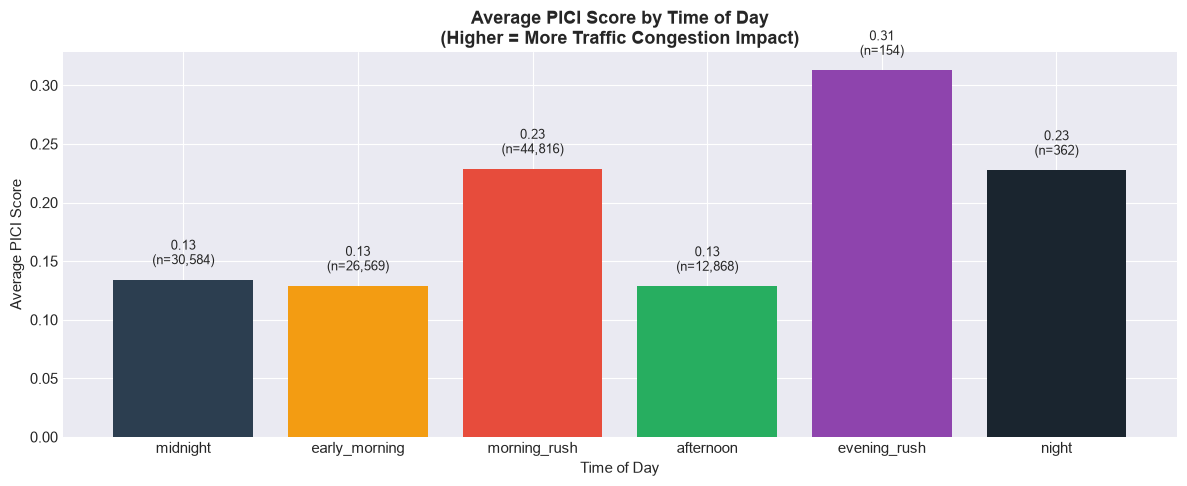

In [37]:
# PICI score by time of day — critical for patrol scheduling
tod_order = ['midnight','early_morning','morning_rush','afternoon','evening_rush','night']
tod_pici = df.groupby('time_of_day')['pici_score'].agg(['mean','count']).reindex(
    [t for t in tod_order if t in df['time_of_day'].unique()]
)

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(tod_pici.index, tod_pici['mean'],
              color=['#2c3e50','#f39c12','#e74c3c','#27ae60','#8e44ad','#1a252f'][:len(tod_pici)])
ax.set_xlabel('Time of Day')
ax.set_ylabel('Average PICI Score')
ax.set_title('Average PICI Score by Time of Day\n(Higher = More Traffic Congestion Impact)', fontweight='bold')
for bar, (_, row) in zip(bars, tod_pici.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{row['mean']:.2f}\n(n={int(row['count']):,})",
            ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

## 7. Enforcement Gap Features

In [38]:
# Validation lag (hours) — already may exist from EDA parquet
if 'validation_lag_hours' not in df.columns:
    df_with_ts = (
        df['validation_timestamp'].notna() & df['created_datetime'].notna()
    )
    df['validation_lag_hours'] = np.nan
    df.loc[df_with_ts, 'validation_lag_hours'] = (
        df.loc[df_with_ts, 'validation_timestamp'] - df.loc[df_with_ts, 'created_datetime']
    ).dt.total_seconds() / 3600
    # Remove impossible negative lags (data entry anomalies)
    df.loc[df['validation_lag_hours'] < 0, 'validation_lag_hours'] = np.nan

# Enforcement gap flag: validation took >48 hours = slow enforcement
df['slow_enforcement'] = (df['validation_lag_hours'] > 48).astype('Int64').fillna(0).astype(int)

# Case never closed flag (closed_datetime is NULL)
df['case_never_closed'] = df['closed_datetime'].isna().astype(int)

print('Slow enforcement (>48h validation lag):')
print(df['slow_enforcement'].value_counts())
print(f"\nCase never closed: {df['case_never_closed'].mean()*100:.1f}% of approved records")

# Per-station enforcement lag analysis
station_lag = df.groupby('police_station')['validation_lag_hours'].agg(['median','mean','count'])
station_lag.columns = ['median_lag_hours','mean_lag_hours','violation_count']
station_lag = station_lag[station_lag['violation_count'] >= 50].sort_values('median_lag_hours', ascending=False)

print('\nTop 10 slowest stations (median validation lag, min 50 records):')
print(station_lag.head(10).round(1))

Slow enforcement (>48h validation lag):
slow_enforcement
0    73058
1    42295
Name: count, dtype: int64

Case never closed: 100.0% of approved records

Top 10 slowest stations (median validation lag, min 50 records):
                   median_lag_hours  mean_lag_hours  violation_count
police_station                                                      
K.S. Layout                    49.9           172.0              338
Kamakshipalya                  47.1           129.8              631
No Police Station              46.9            65.6               77
Yelahanka                      46.0            86.3             1158
J.P. Nagar                     45.8           144.0              645
Whitefield                     45.7           128.8              719
Electronic City                45.2           105.6             1235
Thalagattapura                 45.1            96.5              389
Hennuru                        44.9           115.2              300
Kengeri                

## 8. Repeat Offender Features

**Key insight from EDA:** Some vehicles appear many times across the dataset.
We flag vehicles with 3+ violations as repeat offenders — they contribute disproportionately to chronic hotspots.

In [39]:
# Use final_vehicle_number (corrected) — from EDA
if 'final_vehicle_number' not in df.columns:
    df['final_vehicle_number'] = df['updated_vehicle_number'].fillna(df['vehicle_number'])

# Count violations per vehicle across the ENTIRE dataset
vehicle_violation_counts = df['final_vehicle_number'].value_counts().to_dict()
df['vehicle_prior_violations'] = df['final_vehicle_number'].map(vehicle_violation_counts)

# Repeat offender thresholds
REPEAT_THRESHOLD    = 3   # 3+ violations = repeat offender
CHRONIC_THRESHOLD   = 10  # 10+ violations = chronic offender

df['is_repeat_offender']  = (df['vehicle_prior_violations'] >= REPEAT_THRESHOLD).astype(int)
df['is_chronic_offender'] = (df['vehicle_prior_violations'] >= CHRONIC_THRESHOLD).astype(int)

print(f'Repeat offenders (3+ violations) : {df["is_repeat_offender"].sum():,} records')
print(f'Chronic offenders (10+ violations): {df["is_chronic_offender"].sum():,} records')
print(f'\nUnique repeat offender vehicles   : {df[df["is_repeat_offender"]==1]["final_vehicle_number"].nunique():,}')
print(f'Unique chronic offender vehicles  : {df[df["is_chronic_offender"]==1]["final_vehicle_number"].nunique():,}')

print('\nTop 20 worst repeat offenders:')
top_offenders = (
    df.groupby('final_vehicle_number')
    .agg(
        total_violations=('id','count'),
        total_pici=('pici_score','sum'),
        avg_pici=('pici_score','mean'),
        vehicle_type=('final_vehicle_type','first'),
        stations_visited=('police_station','nunique')
    )
    .sort_values('total_violations', ascending=False)
    .head(20)
)
print(top_offenders.round(2))

Repeat offenders (3+ violations) : 12,088 records
Chronic offenders (10+ violations): 1,125 records

Unique repeat offender vehicles   : 2,889
Unique chronic offender vehicles  : 90

Top 20 worst repeat offenders:
                      total_violations  total_pici  avg_pici    vehicle_type  \
final_vehicle_number                                                           
FKN00GL17863                        26        7.29      0.28             CAR   
FKN00GL9771                         23        4.03      0.18             CAR   
FKN00GL15265                        23        2.32      0.10     MOTOR CYCLE   
FKN00GL17388                        18        2.46      0.14         SCOOTER   
FKN00GL1875                         17        2.41      0.14     MOTOR CYCLE   
FKN00GL25480                        17        1.72      0.10         SCOOTER   
FKN00GL1118                         17        3.18      0.19             CAR   
FKN00GL7998                         16        5.53      0.35      

In [40]:
# Repeat offender PICI impact: do repeat offenders have higher PICI?
repeat_pici  = df[df['is_repeat_offender'] == 1]['pici_score']
normal_pici  = df[df['is_repeat_offender'] == 0]['pici_score']

print(f'Mean PICI — repeat offenders : {repeat_pici.mean():.3f}')
print(f'Mean PICI — non-repeat       : {normal_pici.mean():.3f}')
print(f'\nRepeat offenders contribute {repeat_pici.sum()/df["pici_score"].sum()*100:.1f}% of total PICI burden')
print(f'but represent only {df["is_repeat_offender"].mean()*100:.1f}% of records')

Mean PICI — repeat offenders : 0.155
Mean PICI — non-repeat       : 0.171

Repeat offenders contribute 9.6% of total PICI burden
but represent only 10.5% of records


## 9. Location String Feature Extraction

The `location` column is a full address string. We can extract:
1. **Pin code** — 6-digit code in address
2. **Area name** — the first meaningful named place
3. **Road type hint** — does the address mention 'Main Road', 'Cross Road', 'Flyover', etc.?

In [41]:
def extract_pincode(location_str):
    """Extract 6-digit pin code from location string."""
    if pd.isna(location_str):
        return None
    match = re.search(r'Pin-(\d{6})', str(location_str))
    return match.group(1) if match else None

def extract_road_type(location_str):
    """
    Infer road type from address keywords.
    Returns: 'main_road', 'flyover', 'ring_road', 'cross_road', 'other'
    """
    if pd.isna(location_str):
        return 'other'
    loc = str(location_str).lower()
    if 'flyover' in loc or 'overpass' in loc:
        return 'flyover'
    if 'ring road' in loc or 'outer ring' in loc or 'orr' in loc:
        return 'ring_road'
    if 'main road' in loc or 'main rd' in loc:
        return 'main_road'
    if 'cross road' in loc or 'cross rd' in loc or 'cross' in loc:
        return 'cross_road'
    if 'nh ' in loc or 'national highway' in loc:
        return 'national_highway'
    return 'other'

df['pincode']        = df['location'].apply(extract_pincode)
df['road_type_hint'] = df['location'].apply(extract_road_type)

print('Road type hint distribution:')
print(df['road_type_hint'].value_counts())
print(f'\nPin codes extracted: {df["pincode"].notna().sum():,}')
print(f'Unique pin codes   : {df["pincode"].nunique()}')

Road type hint distribution:
road_type_hint
other               67981
main_road           26656
cross_road          13994
ring_road            5957
flyover               712
national_highway       53
Name: count, dtype: int64

Pin codes extracted: 112,669
Unique pin codes   : 106


In [42]:
# Does road type hint correlate with PICI score?
road_pici = df.groupby('road_type_hint')['pici_score'].agg(['mean','count']).sort_values('mean', ascending=False)
print('Average PICI by road type:')
print(road_pici.round(3))

# Insight: flyover and ring road violations should show higher PICI if our scoring is working

Average PICI by road type:
                   mean  count
road_type_hint                
flyover           0.243    712
national_highway  0.201     53
ring_road         0.190   5957
other             0.172  67981
main_road         0.167  26656
cross_road        0.147  13994


## 10. Final Feature Summary & Export

In [43]:
# Complete list of features in the enriched dataset
print('=== FEATURED DATASET COLUMNS ===')
print(f'Total columns: {len(df.columns)}')
print()

feature_groups = {
    'Original (from EDA)': ['id','latitude','longitude','location','final_vehicle_number',
                              'final_vehicle_type','violation_list','parking_violation_count',
                              'created_datetime','police_station','junction_name','validation_status'],
    'Vehicle Features'   : ['vehicle_category','vehicle_size_factor'],
    'Violation Features' : ['severity_score','multi_vio_factor'],
    'PICI Score'         : ['pici_raw','pici_score','junction_multiplier','peak_hour_multiplier'],
    'Geospatial'         : ['lat_grid','lng_grid','grid_cell'],
    'Temporal'           : ['hour','day_of_week','month','is_peak_hour','is_weekend',
                              'time_of_day','is_business_hours','season'],
    'Enforcement'        : ['validation_lag_hours','slow_enforcement','case_never_closed'],
    'Repeat Offenders'   : ['vehicle_prior_violations','is_repeat_offender','is_chronic_offender'],
    'Location Context'   : ['pincode','road_type_hint'],
}

for group, cols in feature_groups.items():
    available = [c for c in cols if c in df.columns]
    print(f'{group}:')
    for c in available:
        print(f'  ✅ {c}')
    print()

=== FEATURED DATASET COLUMNS ===
Total columns: 69

Original (from EDA):
  ✅ id
  ✅ latitude
  ✅ longitude
  ✅ location
  ✅ final_vehicle_number
  ✅ final_vehicle_type
  ✅ violation_list
  ✅ parking_violation_count
  ✅ created_datetime
  ✅ police_station
  ✅ junction_name
  ✅ validation_status

Vehicle Features:
  ✅ vehicle_category
  ✅ vehicle_size_factor

Violation Features:
  ✅ severity_score
  ✅ multi_vio_factor

PICI Score:
  ✅ pici_raw
  ✅ pici_score
  ✅ junction_multiplier
  ✅ peak_hour_multiplier

Geospatial:
  ✅ lat_grid
  ✅ lng_grid
  ✅ grid_cell

Temporal:
  ✅ hour
  ✅ day_of_week
  ✅ month
  ✅ is_peak_hour
  ✅ is_weekend
  ✅ time_of_day
  ✅ is_business_hours
  ✅ season

Enforcement:
  ✅ validation_lag_hours
  ✅ slow_enforcement
  ✅ case_never_closed

Repeat Offenders:
  ✅ vehicle_prior_violations
  ✅ is_repeat_offender
  ✅ is_chronic_offender

Location Context:
  ✅ pincode
  ✅ road_type_hint



In [44]:
# Final null check on engineered features before saving
engineered = ['vehicle_size_factor','vehicle_category','severity_score','multi_vio_factor',
               'junction_multiplier','peak_hour_multiplier','pici_score',
               'lat_grid','lng_grid','grid_cell','time_of_day','is_business_hours',
               'season','is_repeat_offender','road_type_hint']

print('Null check on engineered features:')
nulls = df[engineered].isnull().sum()
print(nulls[nulls > 0] if nulls.any() else 'No nulls in engineered features ✅')

Null check on engineered features:
No nulls in engineered features ✅


In [45]:
# Save enriched dataset
OUT_PATH = '../data/processed/featured_violations.parquet'
df.to_parquet(OUT_PATH, index=False)
print(f'✅ Featured dataset saved: {OUT_PATH}')
print(f'   Shape: {df.shape}')

# Save PICI normalization params — backend needs these to normalize new uploads consistently
import json
NORM_PATH = '../data/processed/pici_norm_params.json'
with open(NORM_PATH, 'w') as f:
    json.dump(PICI_NORM_PARAMS, f, indent=2)
print(f'✅ PICI normalization params saved: {NORM_PATH}')
print(f'   {PICI_NORM_PARAMS}')

✅ Featured dataset saved: ../data/processed/featured_violations.parquet
   Shape: (115353, 69)
✅ PICI normalization params saved: ../data/processed/pici_norm_params.json
   {'pici_min': 3.0, 'pici_max': 405.0}


In [46]:
# Feature engineering summary
print('=' * 65)
print('  🔧 FEATURE ENGINEERING SUMMARY')
print('=' * 65)
print(f"""
📊 DATASET
   Records               : {len(df):>10,}
   Total features        : {len(df.columns):>10}

🚗 VEHICLE FEATURES
   Heavy vehicles (×2.0) : {(df['vehicle_category']=='HEAVY').sum():>10,}
   Medium vehicles (×1.5): {(df['vehicle_category']=='MEDIUM').sum():>10,}
   Two-wheelers (×1.0)   : {(df['vehicle_category']=='TWO_WHEELER').sum():>10,}

🚫 VIOLATION SEVERITY
   Mean severity score   : {df['severity_score'].mean():>10.2f}
   Max severity score    : {df['severity_score'].max():>10}
   Multi-violation (>1)  : {(df['parking_violation_count']>1).sum():>10,}

📍 PICI SCORE
   Mean PICI             : {df['pici_score'].mean():>10.3f} / 10
   Median PICI           : {df['pici_score'].median():>10.3f} / 10
   Max PICI              : {df['pici_score'].max():>10.3f} / 10
   High impact (>5.0)    : {(df['pici_score']>5.0).sum():>10,}

🔁 REPEAT OFFENDERS
   Repeat (3+ violations): {df['is_repeat_offender'].sum():>10,} records
   Chronic (10+)         : {df['is_chronic_offender'].sum():>10,} records

⚡ ENFORCEMENT GAPS
   Slow validation (>48h): {df['slow_enforcement'].sum():>10,}
   Cases never closed    : {df['case_never_closed'].sum():>10,}
""")
print('=' * 65)
print('  ✅ Ready for Notebook 03: DBSCAN Clustering')
print('=' * 65)

  🔧 FEATURE ENGINEERING SUMMARY

📊 DATASET
   Records               :    115,353
   Total features        :         69

🚗 VEHICLE FEATURES
   Heavy vehicles (×2.0) :      3,288
   Medium vehicles (×1.5):     41,540
   Two-wheelers (×1.0)   :     52,505

🚫 VIOLATION SEVERITY
   Mean severity score   :       4.35
   Max severity score    :         51
   Multi-violation (>1)  :     12,002

📍 PICI SCORE
   Mean PICI             :      0.169 / 10
   Median PICI           :      0.124 / 10
   Max PICI              :     10.000 / 10
   High impact (>5.0)    :          2

🔁 REPEAT OFFENDERS
   Repeat (3+ violations):     12,088 records
   Chronic (10+)         :      1,125 records

⚡ ENFORCEMENT GAPS
   Slow validation (>48h):     42,295
   Cases never closed    :    115,353

  ✅ Ready for Notebook 03: DBSCAN Clustering
